# Symbolic Computation for Differential Equation

Differential equations describe how physical quantities evolve in space and time. In this notebook, SymPy is used to formulate, manipulate, verify, and solve ordinary and partial differential equations symbolically, followed by numerical visualization of representative solutions.

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({ "font.family": "Times New Roman", "mathtext.fontset": "cm", "font.size": 14 })

## Damped Harmonic Oscillator

Define the symbolic variables and physical parameters used throughout this example.

In [2]:
x0, v0 = sp.symbols("x_0 v_0", real=True)
t = sp.symbols("t", real=True)
m, c, k = sp.symbols("m c k", positive=True)
x = sp.Function("x")(t)

The damped harmonic oscillator satisfies:

In [3]:
ode = sp.Eq(m * sp.diff(x, t, 2) + c * sp.diff(x, t) + k * x, 0)
ode

Eq(c*Derivative(x(t), t) + k*x(t) + m*Derivative(x(t), (t, 2)), 0)

Solve the differential equation symbolically.

In [4]:
sp.dsolve(ode)

Eq(x(t), C1*exp(t*(-c + sqrt(c**2 - 4*k*m))/(2*m)) + C2*exp(-t*(c + sqrt(c**2 - 4*k*m))/(2*m)))

The natural frequency $\omega_n$ and damping ratio $\zeta$ are

In [5]:
omega_n = sp.sqrt(k/m)
omega_n

sqrt(k)/sqrt(m)

In [6]:
zeta = c / (2*sp.sqrt(k*m))
zeta

c/(2*sqrt(k)*sqrt(m))

Apply the initial conditions
$$x(0)=x_0,\,\dot{x}(0)=v_0$$

In [7]:
ics = {
    x.subs(t, 0): x0,
    sp.diff(x, t).subs(t, 0): v0
}

solution_ics = sp.dsolve(ode, ics=ics)
solution_ics

Eq(x(t), (-c*x_0/(2*sqrt(c**2 - 4*k*m)) - m*v_0/sqrt(c**2 - 4*k*m) + x_0/2)*exp(-t*(c + sqrt(c**2 - 4*k*m))/(2*m)) + (c*x_0/(2*sqrt(c**2 - 4*k*m)) + m*v_0/sqrt(c**2 - 4*k*m) + x_0/2)*exp(t*(-c + sqrt(c**2 - 4*k*m))/(2*m)))

In [8]:
x_t = solution_ics.rhs
x_t

(-c*x_0/(2*sqrt(c**2 - 4*k*m)) - m*v_0/sqrt(c**2 - 4*k*m) + x_0/2)*exp(-t*(c + sqrt(c**2 - 4*k*m))/(2*m)) + (c*x_0/(2*sqrt(c**2 - 4*k*m)) + m*v_0/sqrt(c**2 - 4*k*m) + x_0/2)*exp(t*(-c + sqrt(c**2 - 4*k*m))/(2*m))

The symbolic solution is evaluated numerically to compare the underdamped and overdamped responses.

In [9]:
t_vals = np.linspace(0, 10, 1000)
cases = {
    "Underdamped": 1,
    "Overdamped": 9
}

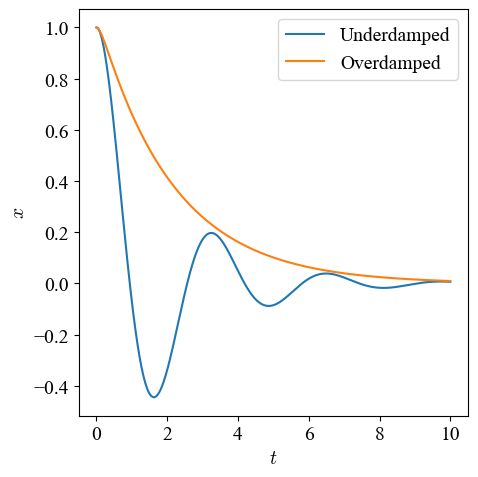

In [10]:
plt.figure(figsize=(5, 5))
for label, c_vals in cases.items():
    x_num = sp.lambdify(t, x_t.subs({m: 1, k: 4, c: c_vals, x0: 1, v0: 0}), "numpy")
    plt.plot(t_vals, np.real([x_num(ti) for ti in t_vals]), label=label)
plt.xlabel(r"$t$")
plt.ylabel(r"$x$")
plt.legend()
plt.tight_layout()
plt.show()

## Advection

Define the symbolic variables and physical parameters used throughout this example.

In [11]:
x, t = sp.symbols("x t", real=True)
c = sp.symbols("c", positive=True)
u = sp.Function("u")(x, t)

The one-dimensional advection equation

$$\partial_t u=-c\partial_x u$$

describes the transport of a scalar quantity moving with a constant velocity without changing its shape.

In [12]:
sp.Eq(sp.diff(u, t), -c * sp.diff(u, x))

Eq(Derivative(u(x, t), t), -c*Derivative(u(x, t), x))

A traveling-wave solution is given by

$$u(x,t)=f(x-ct)$$

where $f$ is an arbitrary differentiable function. This form represents a wave propagating in the positive $x$-direction with constant speed $c$. The following code verifies that the traveling-wave solution satisfies the advection equation by substituting it into the governing equation.

In [13]:
f = sp.Function("f")
sp.simplify(sp.diff(f(x - c * t), t) + c * sp.diff(f(x - c * t), x))

0

Consider the Gaussian pulse

$$u(x,t)=e^{-(x-ct)^2}$$

which propagates without changing its shape.

In [14]:
u_expr = sp.exp(-(x - c * t)**2)
u_func = sp.lambdify((x, t, c), u_expr, "numpy")
x_vals = np.linspace(-5, 5, 500)
t_vals = np.linspace(0, 5, 500)
c_val = 1

In [15]:
X, T = np.meshgrid(x_vals, t_vals)
U = u_func(X, T, c_val)

The following surface plot illustrates the propagation of the Gaussian pulse as a function of space and time.

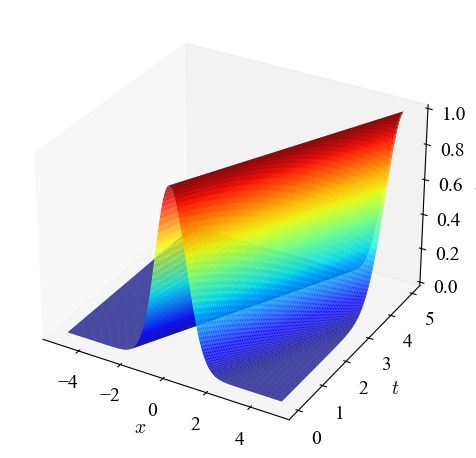

In [16]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.grid(False)
ax.plot_surface(X, T, U, cmap="jet", rstride=2, cstride=2)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
ax.set_zlabel(r"$u$")
plt.tight_layout()
plt.show()

## Heat Equation

Define the symbolic variables and physical parameters used throughout this example.

In [17]:
x, t = sp.symbols("x t", real=True)
kappa = sp.symbols("kappa", positive=True)
u = sp.Function("u")(x, t)

The one-dimensional heat equation

$$\partial_t u=\kappa\partial_x^2 u$$

models the diffusion of heat through a homogeneous medium, where $\kappa$ denotes the thermal diffusivity.

In [18]:
sp.Eq(sp.diff(u, t), kappa * sp.diff(u, x, 2))

Eq(Derivative(u(x, t), t), kappa*Derivative(u(x, t), (x, 2)))

One analytical solution is the Gaussian fundamental solution

$$u(x,t)=\frac{1}{\sqrt{4\pi\kappa t}}e^{-x^2/{4\kappa t}}$$

which satisfies the one-dimensional heat equation. The following code substitutes the analytical solution into the governing equation to verify that it satisfies the heat equation.

In [19]:
u_expr = (1/sp.sqrt(4*sp.pi*kappa*t)) * sp.exp(-x**2/(4*kappa*t))
sp.simplify(sp.diff(u_expr, t) - kappa * sp.diff(u_expr, x, 2))

0

Evaluate the Gaussian solution for a representative value of the thermal diffusivity.

In [20]:
u_func = sp.lambdify((x, t, kappa), u_expr, "numpy")
x_vals = np.linspace(-5, 5, 500)
t_vals = np.linspace(1e-1, 2, 500)
kappa_val = 1

In [21]:
X, T = np.meshgrid(x_vals, t_vals)
U = u_func(X, T, kappa_val)

The surface plot below illustrates the diffusion of the initial Gaussian profile. As time increases, the distribution spreads while its peak amplitude decreases.

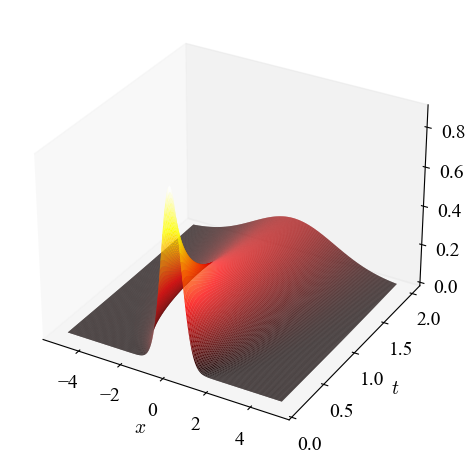

In [22]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.grid(False)
ax.plot_surface(X, T, U, cmap="hot", rstride=2, cstride=2)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
ax.set_zlabel(r"$u$")
plt.tight_layout()
plt.show()

## Wave Equation

Define the symbolic variables and physical parameters used throughout this example.

In [23]:
x, t = sp.symbols("x t", real=True)
c = sp.symbols("c", positive=True)
u = sp.Function("u")(x, t)

The one-dimensional wave equation

$$\partial_t^2 u=c^2\partial_x^2 u$$

describes the propagation of mechanical and electromagnetic disturbances, which $c$ is the wave propagation speed.

In [24]:
sp.Eq(sp.diff(u, t, 2), c**2 * sp.diff(u, x, 2))

Eq(Derivative(u(x, t), (t, 2)), c**2*Derivative(u(x, t), (x, 2)))

According to d'Alembert's solution, the general solution can be expressed as

$$u(x,t)=f(x-ct)+g(x+ct)$$

where $f$ and $g$ represent right- and left-traveling waves, respectively.

In [25]:
f = sp.exp(-(x - c * t)**2)
g = sp.exp(-(x + c * t)**2)
u_expr = f + g
u_expr

exp(-(c*t + x)**2) + exp(-(-c*t + x)**2)

The following code verifies that the selected wave profile satisfies the governing equation.

In [26]:
sp.simplify(sp.diff(u_expr, t, 2) - c**2 * sp.diff(u_expr, x, 2))

0

Consider the superposition of two Gaussian wave packets traveling in opposite directions.

In [27]:
u_func = sp.lambdify((x, t, c), u_expr, "numpy")
x_vals = np.linspace(-10, 10, 500)
t_vals = np.linspace(0, 5, 500)
c_val = 1

In [28]:
X, T = np.meshgrid(x_vals, t_vals)
U = u_func(X, T, c_val)

The surface plot illustrates the propagation and superposition of the two wave packets over time.

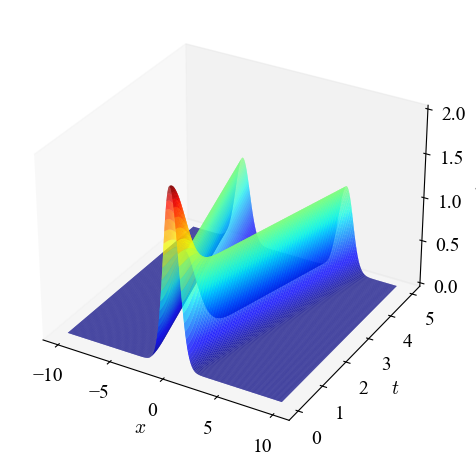

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.grid(False)
ax.plot_surface(X, T, U, cmap="jet", rstride=2, cstride=2)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
ax.set_zlabel(r"$u$")
plt.tight_layout()
plt.show()

## Schrödinger Equation

Define the symbolic variables and physical parameters used throughout this example.

In [30]:
x, t = sp.symbols("x t", real=True)
m, k, hbar, sigma = sp.symbols("m k hbar sigma", positive=True)
psi = sp.Function("psi")(x, t)

The one-dimensional time-dependent Schrödinger equation

$$i\hbar\partial_t\psi=-\frac{\hbar^2}{2m}\partial_x^2\psi$$

governs the evolution of a quantum wave function, where $m$ is the particle mass and $\hbar$ is the reduced Planck constant.

In [31]:
sp.Eq(sp.I*hbar*sp.diff(psi, t), -(hbar**2/(2*m))*sp.diff(psi, x, 2))

Eq(I*hbar*Derivative(psi(x, t), t), -hbar**2*Derivative(psi(x, t), (x, 2))/(2*m))

Consider a free-particle Gaussian wave packet $\psi(x,t)$, whose analytical expression is defined in the following code cell.

In [32]:
alpha = hbar/(m*sigma**2)
omega = hbar*k**2/(2*m)
v = hbar*k/m

In [33]:
psi_expr = (1/sp.sqrt(1 + sp.I*alpha*t)) * sp.exp(-(x - v*t)**2/(2*sigma**2*(1 + sp.I*alpha*t))) * sp.exp(sp.I*(k*x - omega*t))

The following code verifies that the Gaussian wave packet satisfies the time-dependent Schrödinger equation.

In [34]:
sp.simplify(sp.I*hbar*sp.diff(psi_expr, t) + (hbar**2/(2*m))*sp.diff(psi_expr, x, 2))

0

The probability density associated with the wave function is computed as

$${|\psi(x,t)|}^2$$

The resulting expression is simplified symbolically before numerical evaluation.

In [35]:
prob_expr = (1/sp.sqrt(1 + (alpha*t)**2)) * sp.exp(-(x - v*t)**2/(sigma**2*(1 + (alpha*t)**2)))
prob_expr

exp(-(-hbar*k*t/m + x)**2/(sigma**2*(hbar**2*t**2/(m**2*sigma**4) + 1)))/sqrt(hbar**2*t**2/(m**2*sigma**4) + 1)

Evaluate the probability density for representative values of the physical parameters.

In [36]:
prob_func = sp.lambdify((x, t, k, m, hbar, sigma), prob_expr, "numpy")
x_vals = np.linspace(-10, 10, 500)
t_vals = np.linspace(0, 10, 500)
k_val = 2
m_val = 1
hbar_val = 1
sigma_val = 1

In [37]:
X, T = np.meshgrid(x_vals, t_vals)
U = prob_func(X, T, k_val, m_val, hbar_val, sigma_val)

The surface plot illustrates the time evolution of the probability density. As the wave packet propagates, its center moves while the distribution gradually spreads due to dispersion.

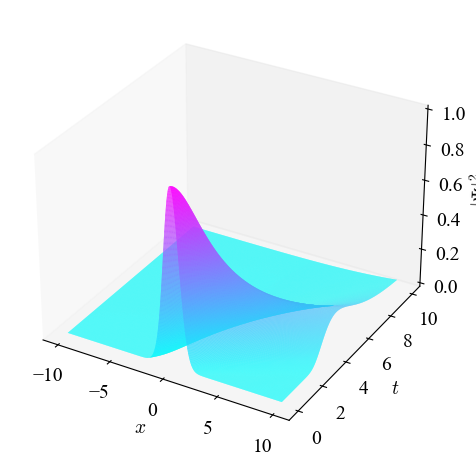

In [38]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
ax.grid(False)
ax.plot_surface(X, T, U, cmap="cool", cstride=1, rstride=1)
ax.set_xlabel(r"$x$")
ax.set_ylabel(r"$t$")
ax.set_zlabel(r"$|\Psi|^2$")
plt.tight_layout()
plt.show()

## Key Insights

* Symbolic computation enables differential equations to be formulated, solved, and verified analytically before numerical implementation.
* Combining symbolic computation with visualization improves both mathematical understanding and physical interpretation.